In [20]:
import pandas as pd           

df = pd.read_csv('Social_Media_Content_Performance_Dataset.csv')

df['Post_Date'] = pd.to_datetime(df['Post_Date'], format='mixed', dayfirst=True)

num_cols = ['Engagement_Rate', 'Views', 'Clicks', 'Click_Through_Rate']
for col in num_cols:
    df[col] = pd.to_numeric(df[col], errors='coerce')

df['Clicks'] = df['Clicks'].fillna(0)
df['Views'] = df['Views'].fillna(0)

df['DayOfWeek'] = df['Post_Date'].dt.day_name() 
df['Post_Hour'] = df['Post_Date'].dt.hour   

print("Complete! Data ready!")

Complete! Data ready!


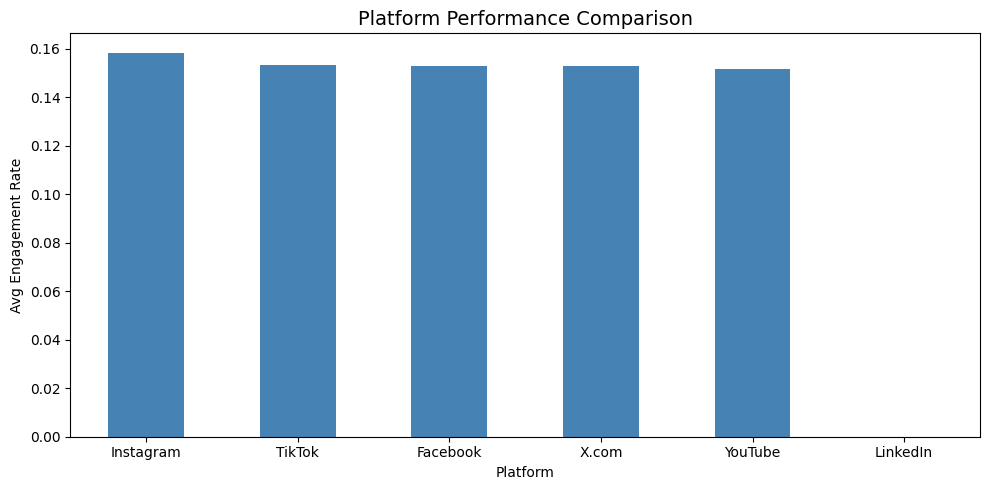

In [27]:
platform_er = df.groupby('Platform')['Engagement_Rate'].mean().sort_values(ascending=False)


plt.figure(figsize=(10, 5))
platform_er.plot(kind='bar', color='steelblue', edgecolor='none')

plt.title('Platform Performance Comparison', fontsize=14)
plt.xlabel('Platform')
plt.ylabel('Avg Engagement Rate')
plt.xticks(rotation=0)    # xoay label ngang cho dễ đọc
plt.tight_layout()
plt.savefig('platform_er.png', dpi=150)  # lưu ảnh
plt.show()

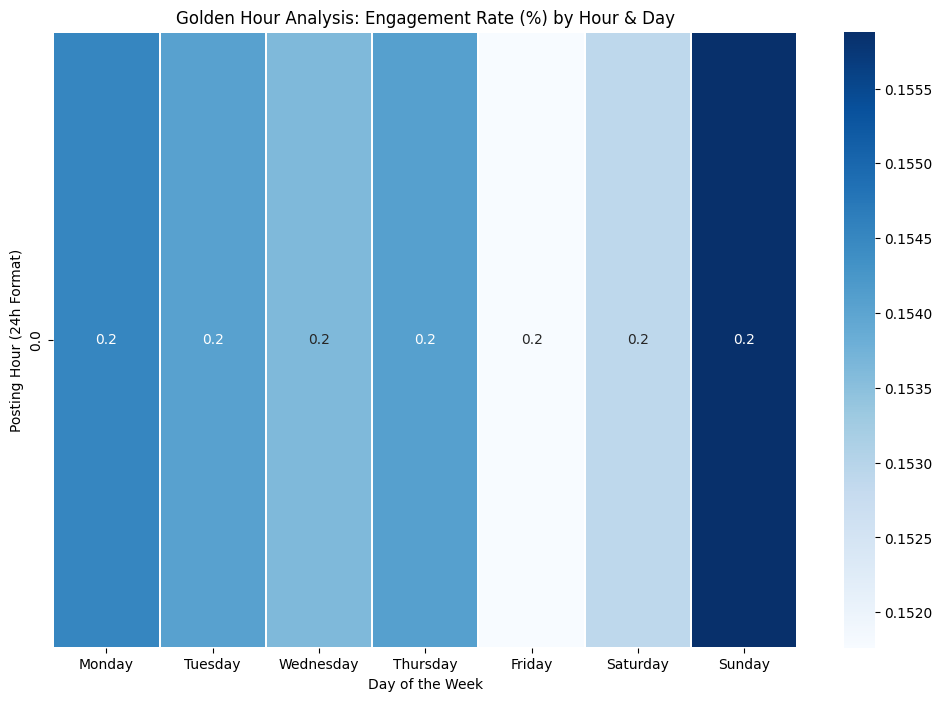

In [3]:
df = pd.read_csv('Social_Media_Content_Performance_Dataset.csv')


df['Engagement_Rate'] = df['Engagement_Rate'].astype(str).str.replace('%', '').str.strip()
df['Engagement_Rate'] = pd.to_numeric(df['Engagement_Rate'], errors='coerce')


df = df.dropna(subset=['Engagement_Rate'])


if df['Engagement_Rate'].mean() > 1:
    df['Engagement_Rate'] = df['Engagement_Rate'] / 100


df['Post_Date'] = pd.to_datetime(df['Post_Date'], errors='coerce')
df['DayOfWeek'] = df['Post_Date'].dt.day_name()
df['Post_Hour'] = df['Post_Date'].dt.hour


DOW_ORDER = ['Monday','Tuesday','Wednesday','Thursday','Friday','Saturday','Sunday']

heatmap_data = df.groupby(['Post_Hour', 'DayOfWeek'])['Engagement_Rate'] \
                 .mean().unstack().reindex(columns=DOW_ORDER)

plt.figure(figsize=(12, 8))
sns.heatmap(heatmap_data * 100, cmap='Blues', annot=True, fmt='.1f', linewidths=0.3)

plt.title('Golden Hour Analysis: Engagement Rate (%) by Hour & Day')
plt.xlabel('Day of the Week')
plt.ylabel('Posting Hour (24h Format)')
plt.show()

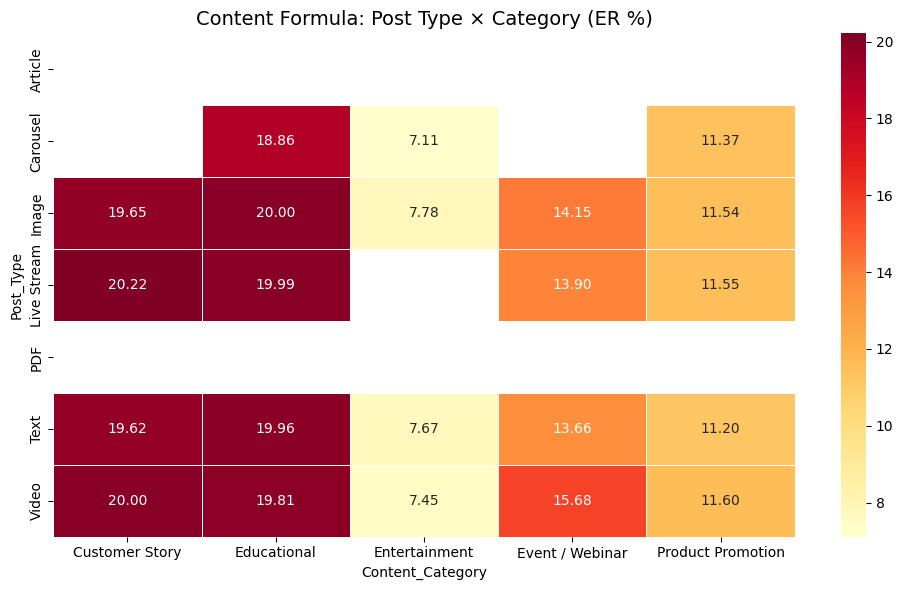

In [32]:
formula = df.groupby(['Post_Type', 'Content_Category'])['Engagement_Rate'] \
             .mean() \
             .reset_index() \
             .pivot(index='Post_Type', columns='Content_Category', values='Engagement_Rate')

plt.figure(figsize=(10, 6))
sns.heatmap(formula * 100,
            cmap='YlOrRd',    
            annot=True,      
            fmt='.2f',
            linewidths=0.5)

plt.title('Content Formula: Post Type × Category (ER %)', fontsize=14)
plt.tight_layout()
plt.savefig('content_formula.png', dpi=150)
plt.show()